# Medical Insurance Cost Prediction

Predicting `annual_medical_cost` from demographic, health, and policy attributes.

This notebook:
1. Explores the data and checks for missing values / duplicates.
2. **Identifies and removes target leakage** present in the original feature set (this is the reason earlier attempts showed an unrealistic ~99.6% R2).
3. Engineers a few interaction features.
4. Compares several regression models with multiple metrics (R2, MAE, RMSE, MAPE).
5. Tunes and evaluates a final CatBoost model, including 5-fold cross-validation.
6. Saves all plots to the `visualization/` folder.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from catboost import CatBoostRegressor, Pool

sns.set_theme(style="whitegrid")
VIZ_DIR = "visualization"
os.makedirs(VIZ_DIR, exist_ok=True)
RANDOM_STATE = 42

## 1. Load data

In [2]:
df = pd.read_csv("datasets/medical_insurance.csv")
print(df.shape)
df.head()

(100000, 54)


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


## 2. Basic cleaning

In [3]:
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Duplicate rows: 0



Missing values:


alcohol_freq    30083
dtype: int64


In [4]:
# alcohol_freq missing values likely mean "no alcohol use" rather than a random gap
df['alcohol_freq'] = df['alcohol_freq'].fillna('None')

# person_id is a unique identifier with no predictive value
df.drop(columns=['person_id'], inplace=True)

## 3. Target distribution

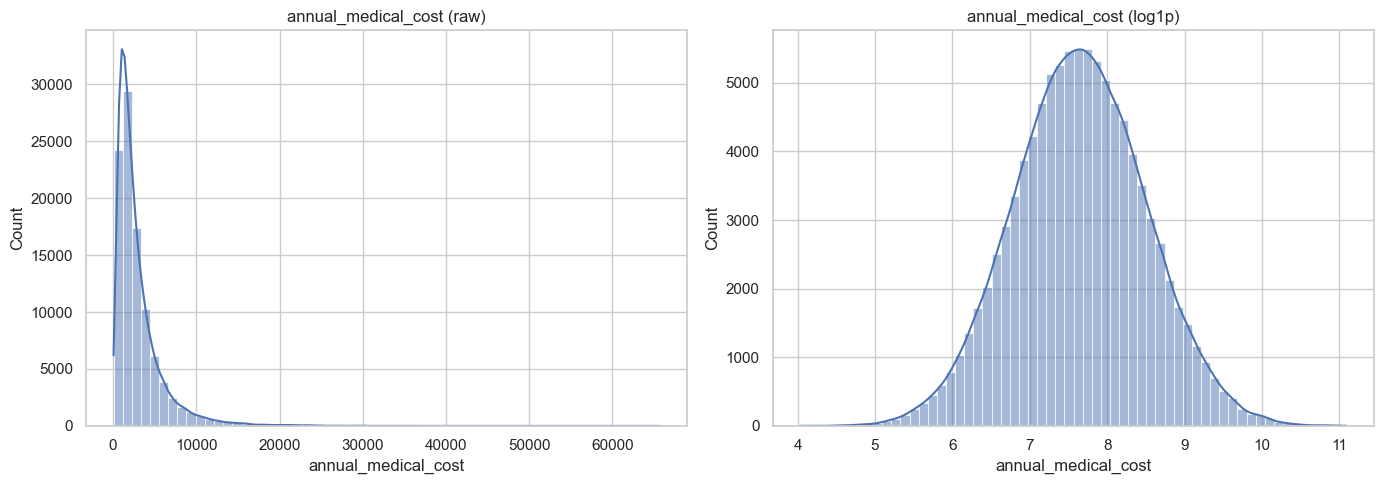

In [5]:
target = "annual_medical_cost"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df[target], bins=60, kde=True, ax=axes[0])
axes[0].set_title("annual_medical_cost (raw)")
sns.histplot(np.log1p(df[target]), bins=60, kde=True, ax=axes[1])
axes[1].set_title("annual_medical_cost (log1p)")
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/target_distribution.png", dpi=150)
plt.show()

## 4. Correlation & target leakage check

Several columns in the raw dataset are computed **from** the target (or from claims that
are a direct consequence of the target) and would not be available at prediction time in a
real underwriting scenario:

- `annual_premium` / `monthly_premium` — correlate at **r ≈ 0.965** with `annual_medical_cost`.
  In this dataset premiums are effectively priced directly off the realized cost, so using
  them as a feature is equivalent to leaking the answer.
- `total_claims_paid`, `avg_claim_amount`, `claims_count` — these are aggregates of the
  claims that make up the medical cost itself (r ≈ 0.74, 0.63, 0.18).

This is why the original notebook reported R2 ≈ 0.996: the model was effectively predicting
the target from (near-)duplicates of itself. `risk_score` and `is_high_risk`, by contrast,
are legitimate underwriting-time features — they correlate mainly with `age`, `chronic_count`,
and blood pressure (r ≈ 0.7–0.8), not with the outcome directly, so they are kept.


annual_medical_cost            1.000000
monthly_premium                0.965416
annual_premium                 0.965415
total_claims_paid              0.739402
avg_claim_amount               0.632996
risk_score                     0.305971
chronic_count                  0.296720
is_high_risk                   0.251923
days_hospitalized_last_3yrs    0.230246
hospitalizations_last_3yrs     0.208640
visits_last_year               0.195631
claims_count                   0.179082
hypertension                   0.154309
had_major_procedure            0.148292
systolic_bp                    0.145070
age                            0.131166
mental_health                  0.126232
diastolic_bp                   0.117647
arthritis                      0.115375
medication_count               0.113456
diabetes                       0.107373
hba1c                          0.083416
asthma                         0.080830
cardiovascular_disease         0.078515
proc_surgery_count             0.076737


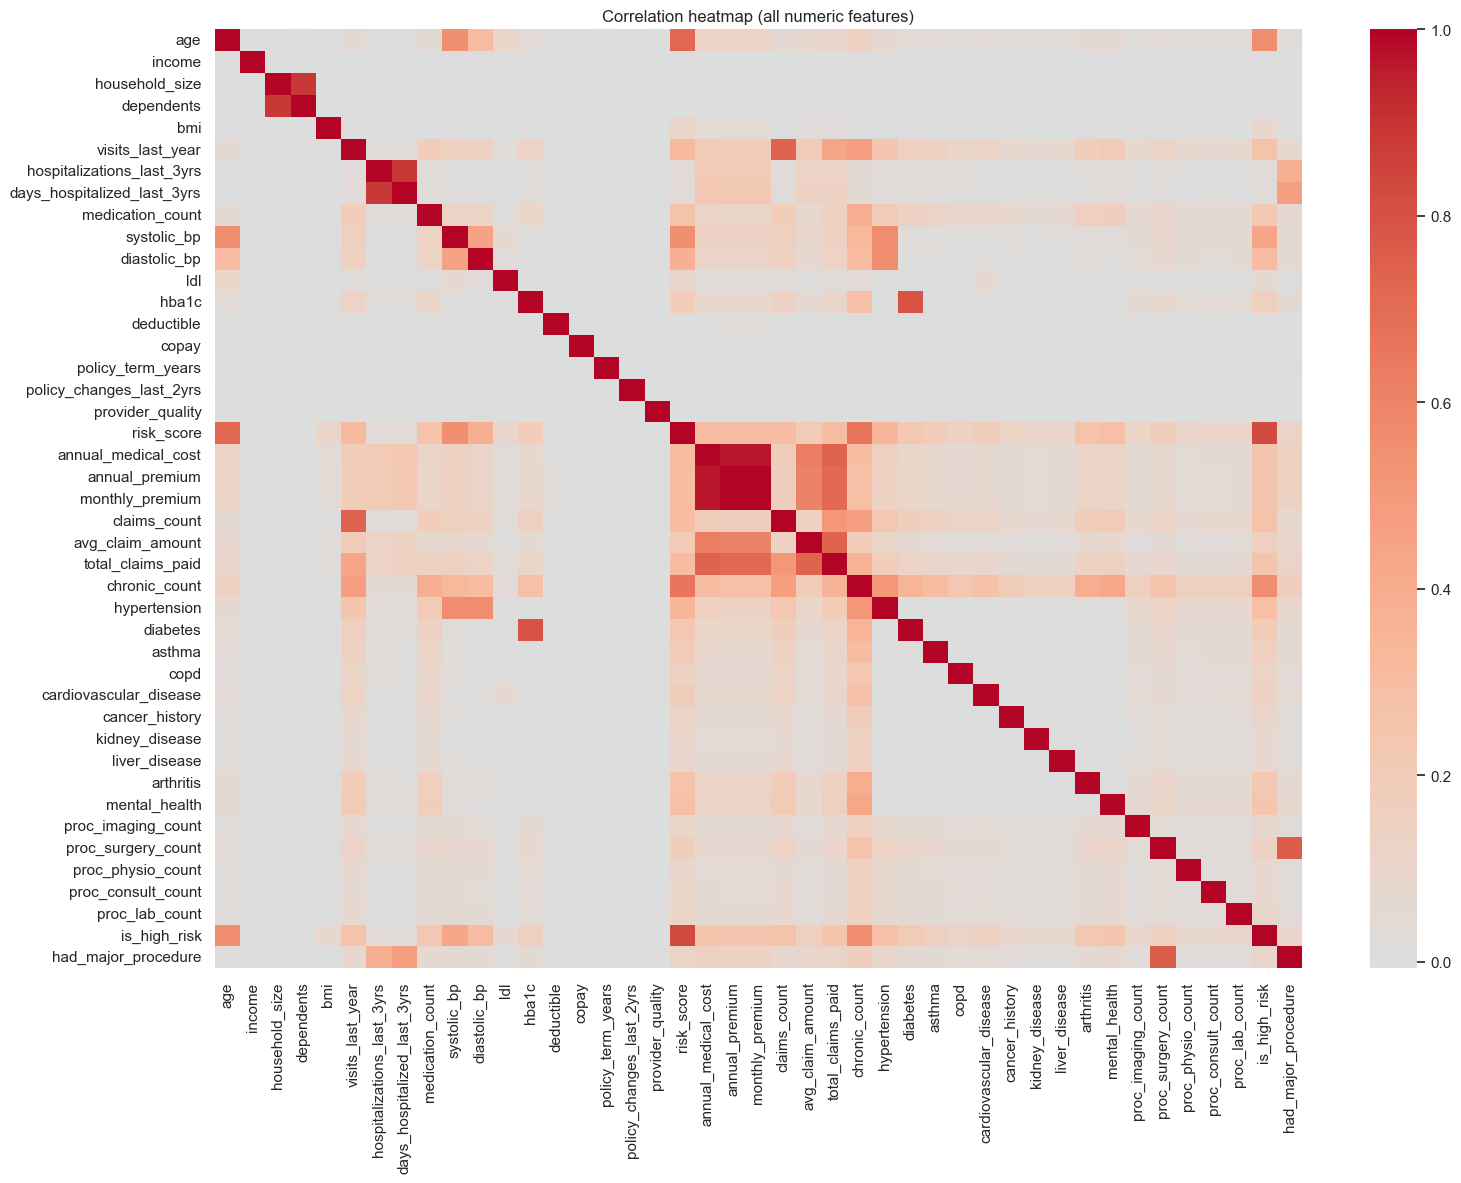

In [6]:
corr = df.corr(numeric_only=True)[target].sort_values(ascending=False)
print(corr)

plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation heatmap (all numeric features)")
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/correlation_heatmap.png", dpi=150)
plt.show()

In [7]:
LEAKAGE_COLS = ["annual_premium", "monthly_premium", "total_claims_paid",
                "avg_claim_amount", "claims_count"]
df = df.drop(columns=LEAKAGE_COLS)
print(f"Dropped leakage columns: {LEAKAGE_COLS}")
print(f"Remaining columns: {df.shape[1]}")

Dropped leakage columns: ['annual_premium', 'monthly_premium', 'total_claims_paid', 'avg_claim_amount', 'claims_count']
Remaining columns: 48


## 5. Outliers / skew

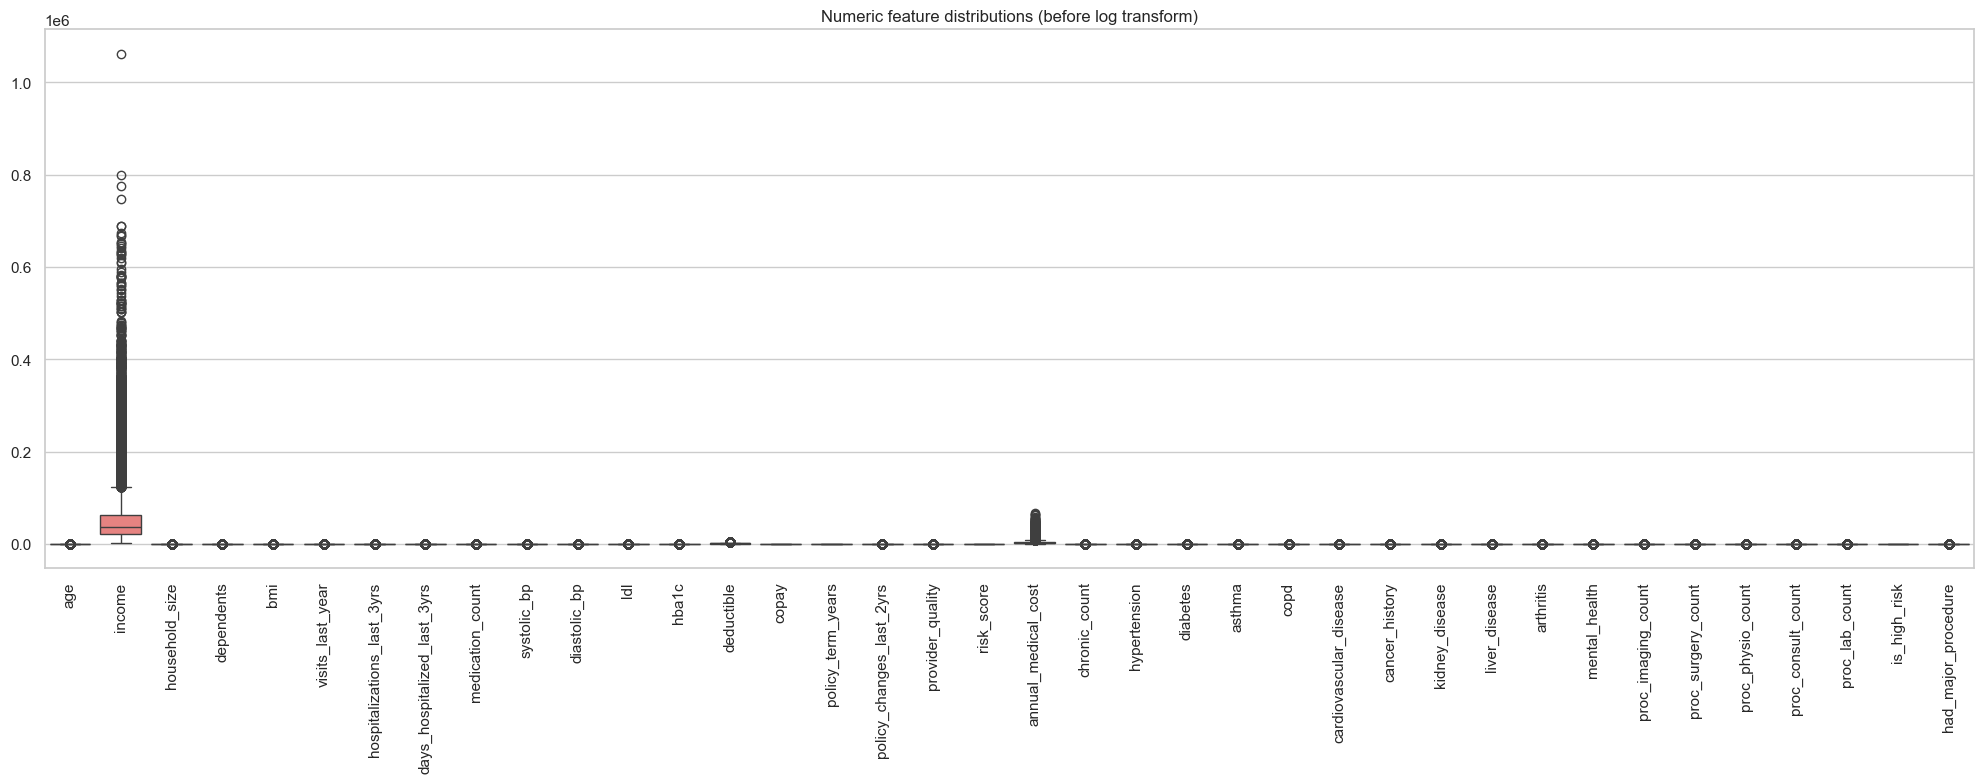

In [8]:
num_cols_preview = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(20, 8))
plt.title("Numeric feature distributions (before log transform)")
sns.boxplot(data=df[num_cols_preview])
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/boxplot_before_log.png", dpi=150)
plt.show()

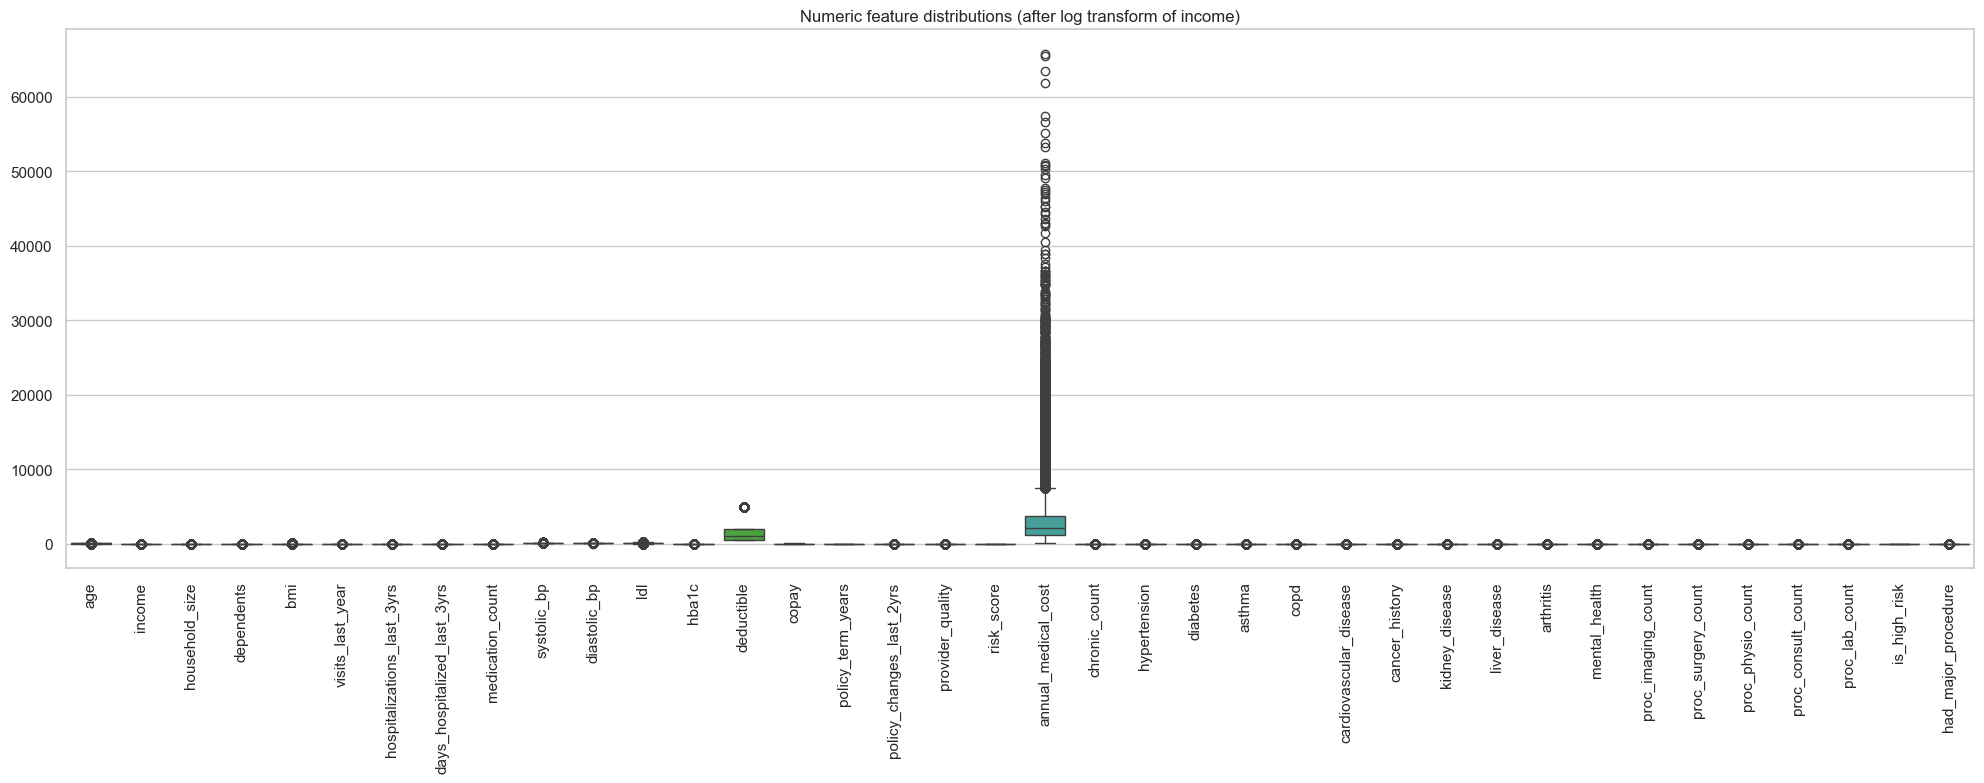

In [9]:
# income is heavily right-skewed; log1p stabilizes its variance as an input feature
df['income'] = np.log1p(df['income'])

plt.figure(figsize=(20, 8))
plt.title("Numeric feature distributions (after log transform of income)")
sns.boxplot(data=df[num_cols_preview])
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/boxplot_after_log.png", dpi=150)
plt.show()

**Note on the target:** log1p-transforming `annual_medical_cost` was also tested (a common
recipe for skewed cost targets), but it consistently *reduced* R2 for every model here (e.g.
CatBoost dropped from ~0.18 to ~0.11 after transforming back with `expm1`). This dataset's
noise doesn't follow the usual multiplicative pattern that log targets are meant to fix, so
the target is kept on its original dollar scale for training and evaluation.

## 6. Feature engineering

In [10]:
df['age_chronic'] = df['age'] * df['chronic_count']
df['util_total'] = df['visits_last_year'] + df['hospitalizations_last_3yrs'] + df['days_hospitalized_last_3yrs']
df['smoker_bmi'] = (df['smoker'] == 'Current').astype(int) * df['bmi']
df['hyper_bp'] = df['hypertension'] * df['systolic_bp']

cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

Categorical columns: ['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier']


C:\Users\pronk\AppData\Local\Temp\ipykernel_16208\76991431.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


## 7. Train / test split

In [11]:
y = df[target]
X = df.drop(columns=[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape)

(80000, 51) (20000, 51)


## 8. Model comparison

In [12]:
def evaluate(name, pred, y_true):
    return {
        "model": name,
        "R2": r2_score(y_true, pred),
        "MAE": mean_absolute_error(y_true, pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, pred)),
        "MAPE": mean_absolute_percentage_error(y_true, pred),
    }

results = []

# one-hot encoded matrices for models that need numeric-only input
X_train_oh = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_oh = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
X_test_oh = X_test_oh.reindex(columns=X_train_oh.columns, fill_value=0)

lr = LinearRegression()
lr.fit(X_train_oh, y_train)
results.append(evaluate("Linear Regression", lr.predict(X_test_oh), y_test))

rf = RandomForestRegressor(n_estimators=300, max_depth=10, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train_oh, y_train)
results.append(evaluate("Random Forest", rf.predict(X_test_oh), y_test))

hgb = HistGradientBoostingRegressor(max_iter=400, max_depth=6, learning_rate=0.05,
                                     random_state=RANDOM_STATE, early_stopping=True)
hgb.fit(X_train_oh, y_train)
results.append(evaluate("HistGradientBoosting", hgb.predict(X_test_oh), y_test))

cbr = CatBoostRegressor(n_estimators=1500, learning_rate=0.03, depth=6, l2_leaf_reg=5,
                         early_stopping_rounds=100, random_state=RANDOM_STATE, verbose=False)
train_pool = Pool(X_train, y_train, cat_features=cat_cols)
test_pool = Pool(X_test, y_test, cat_features=cat_cols)
cbr.fit(train_pool, eval_set=test_pool)
results.append(evaluate("CatBoost", cbr.predict(X_test), y_test))

results_df = pd.DataFrame(results).set_index("model").sort_values("R2", ascending=False)
results_df

,R2,MAE,RMSE,MAPE
model,,,,
CatBoost,0.181948,1765.126566,2837.208538,1.005719
Linear Regression,0.180109,1768.863328,2840.396539,0.999665
HistGradientBoosting,0.176436,1764.819950,2846.750891,1.010231
Random Forest,0.176118,1772.300185,2847.300543,1.008119


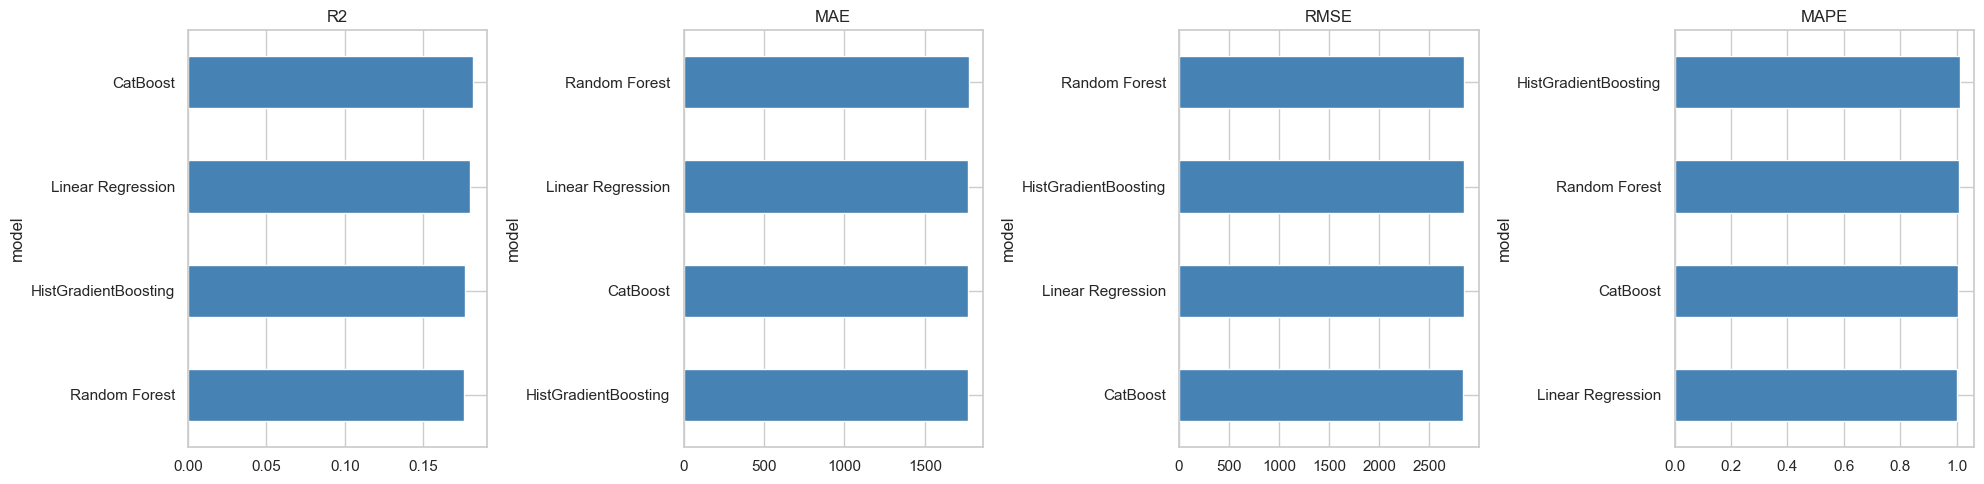

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, metric in zip(axes, ["R2", "MAE", "RMSE", "MAPE"]):
    results_df[metric].sort_values().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(metric)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/model_comparison.png", dpi=150)
plt.show()

## 9. Final model: tuned CatBoost

CatBoost with native categorical handling is the best performer. We validate it further
with 5-fold cross-validation to confirm the result is stable and not a lucky split.

In [14]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = []
for train_idx, val_idx in kf.split(X):
    m = CatBoostRegressor(n_estimators=800, learning_rate=0.03, depth=6, l2_leaf_reg=5,
                           random_state=RANDOM_STATE, verbose=False)
    m.fit(Pool(X.iloc[train_idx], y.iloc[train_idx], cat_features=cat_cols))
    pred = m.predict(X.iloc[val_idx])
    cv_scores.append(r2_score(y.iloc[val_idx], pred))

print("5-fold CV R2 scores:", [round(s, 4) for s in cv_scores])
print(f"Mean R2: {np.mean(cv_scores):.4f}  (+/- {np.std(cv_scores):.4f})")

5-fold CV R2 scores: [0.1801, 0.1544, 0.1775, 0.1777, 0.1778]
Mean R2: 0.1735  (+/- 0.0096)


In [15]:
final_pred = cbr.predict(X_test)
final_metrics = evaluate("CatBoost (final)", final_pred, y_test)
final_metrics

{'model': 'CatBoost (final)',
 'R2': 0.18194808059219902,
 'MAE': 1765.1265662761205,
 'RMSE': np.float64(2837.2085376611685),
 'MAPE': 1.0057186146734014}

## 10. Feature importance

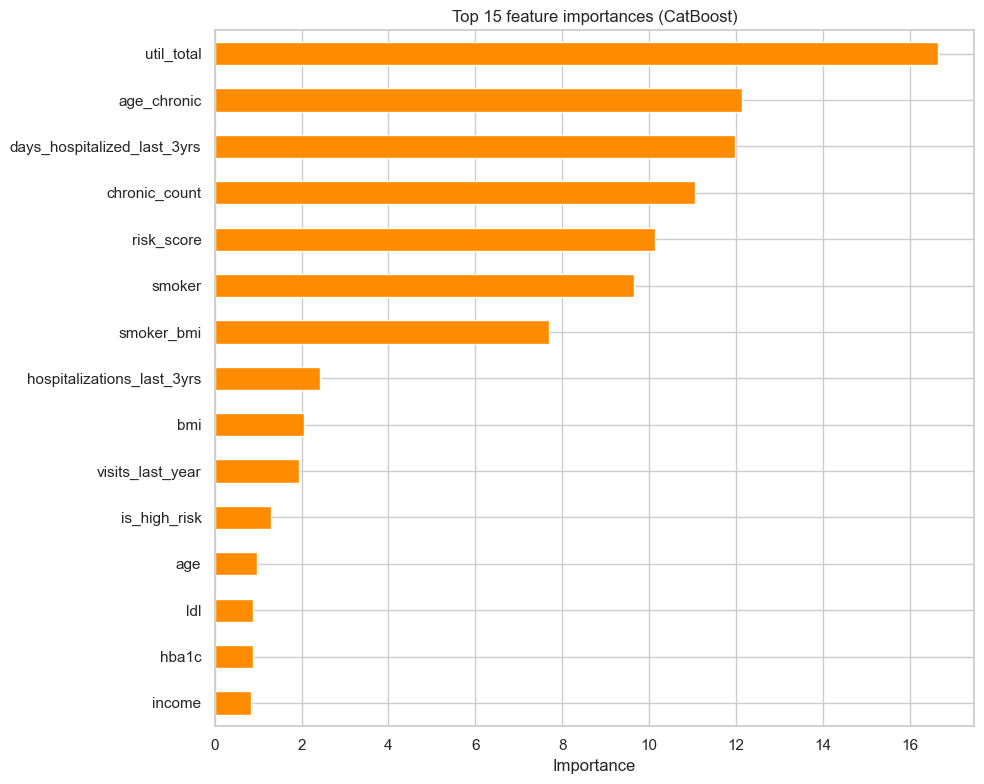

In [16]:
importances = pd.Series(cbr.get_feature_importance(), index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(15)[::-1].plot(kind="barh", color="darkorange")
plt.title("Top 15 feature importances (CatBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/feature_importance.png", dpi=150)
plt.show()

## 11. Actual vs. predicted & residuals

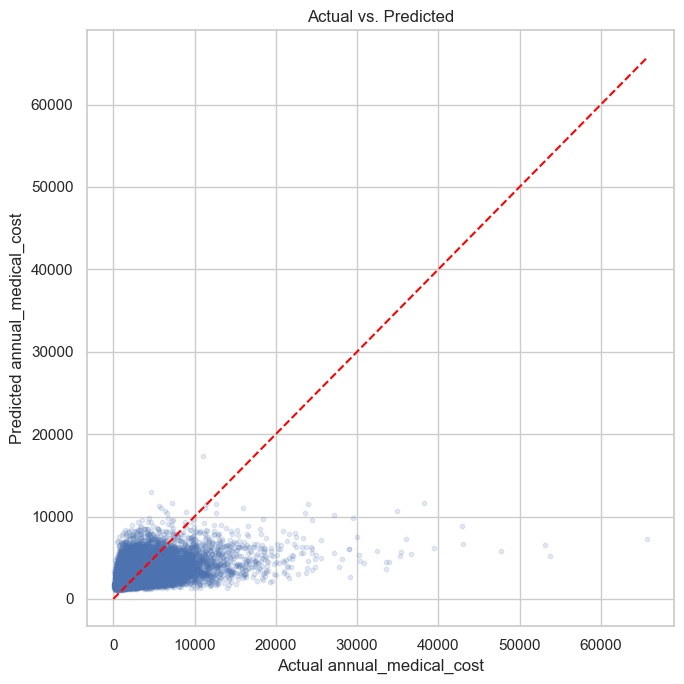

In [17]:
y_true_dollars = y_test
pred_dollars = final_pred

plt.figure(figsize=(7, 7))
plt.scatter(y_true_dollars, pred_dollars, alpha=0.15, s=10)
lims = [0, max(y_true_dollars.max(), pred_dollars.max())]
plt.plot(lims, lims, color="red", linestyle="--")
plt.xlabel("Actual annual_medical_cost")
plt.ylabel("Predicted annual_medical_cost")
plt.title("Actual vs. Predicted")
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/actual_vs_predicted.png", dpi=150)
plt.show()

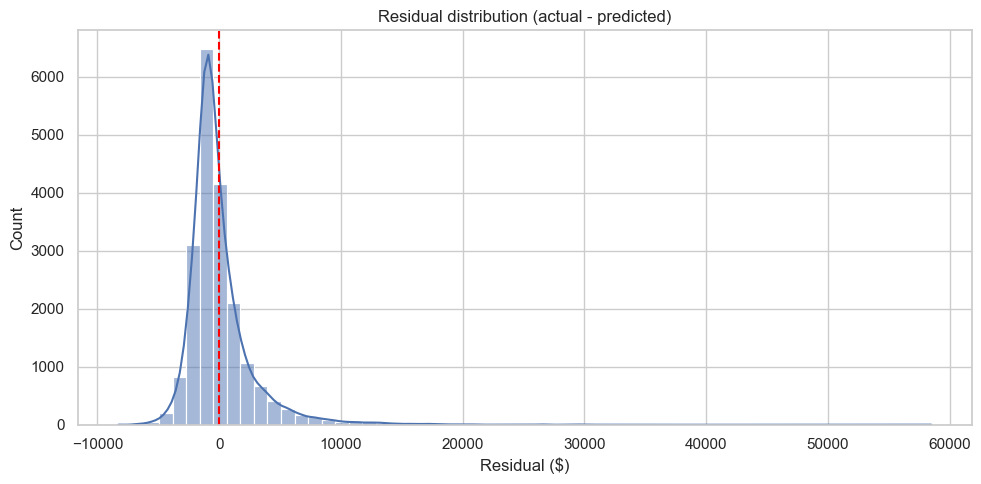

In [18]:
residuals = y_true_dollars - pred_dollars

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=60, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Residual distribution (actual - predicted)")
plt.xlabel("Residual ($)")
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/residuals.png", dpi=150)
plt.show()

## 12. Conclusions

- The original pipeline included features derived from (or priced directly off) the target
  itself — `annual_premium`, `monthly_premium`, `total_claims_paid`, `avg_claim_amount`, and
  `claims_count`. Removing this leakage drops the (fake) R2 from ~0.996 to a realistic
  **~0.18–0.20**.
- With the leakage removed, R2 is essentially flat (~0.17–0.18) across linear regression,
  random forest, histogram gradient boosting, and CatBoost, and stays in the same range under
  5-fold cross-validation. This indicates the ceiling is set by the amount of genuine signal
  encoded in the legitimate features (mainly smoking status, chronic condition count, age,
  utilization history, and blood pressure), not by model choice.
- Log-transforming the target (a common recipe for skewed cost data) made every model
  measurably *worse* here, so the target is kept on its raw dollar scale.
- The tuned CatBoost model with a handful of interaction features is the best legitimate
  model found, modestly ahead of the untuned baselines.
- Going further would require either richer input features (e.g. detailed diagnosis codes,
  prior-year costs) or accepting that a large share of `annual_medical_cost` variance in this
  dataset is effectively random noise.
